In [1]:
# Célula 1: imports
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneOut, cross_validate, cross_val_predict, validation_curve
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
)

In [2]:
# Célula 2: configurações
CSV_PATH = "abalone_dataset.csv"   # ajuste o caminho
RANDOM_STATE = 42

N_ESTIMATORS = 300        # nº de árvores
MAX_DEPTH = 8             # da curva de validação: 5 a 8 rendem o mesmo que profundidades maiores
MIN_SAMPLES_LEAF = 1
K = 10                    # nº de folds

REMOVER_SOMA_INVALIDA = False   # True: remove linhas com shucked+viscera+shell > whole
TOL = 1e-9                      # tolerância para erro de ponto flutuante

In [3]:
# Célula 3: carregar e (opcionalmente) filtrar
df = pd.read_csv(CSV_PATH)
print(df.shape)
print(df["type"].value_counts().sort_index())

X = df.drop(columns="type")
y = df["type"]
cat_cols = ["sex"]
num_cols = [c for c in X.columns if c not in cat_cols]

(3132, 9)
type
1    1078
2    1003
3    1051
Name: count, dtype: int64


In [4]:
# Célula 4: modelo
# Random Forest não precisa de normalização (as divisões das árvores não dependem da escala).
# O one-hot de 'sex' fica dentro do Pipeline, então é ajustado só no treino de cada fold.
def make_model(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH,
               min_samples_leaf=MIN_SAMPLES_LEAF, n_jobs=-1):
    pre = ColumnTransformer(
        [("sex", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
        remainder="passthrough",
    )
    rf = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=RANDOM_STATE, n_jobs=n_jobs,
    )
    return Pipeline([("pre", pre), ("rf", rf)])

In [5]:
# Célula 5: avaliação com K-Fold estratificado (métricas por fold, treino x validação)
cv = StratifiedKFold(n_splits=K, shuffle=True, random_state=RANDOM_STATE)

res = cross_validate(
    make_model(), X, y, cv=cv,
    scoring={"acc": "accuracy", "f1_macro": "f1_macro"},
    return_train_score=True, n_jobs=1,
)

print(f"Acurácia (validação): {res['test_acc'].mean():.4f} ± {res['test_acc'].std():.4f}")
print(f"F1 macro (validação): {res['test_f1_macro'].mean():.4f} ± {res['test_f1_macro'].std():.4f}")
print(f"Acurácia (treino):    {res['train_acc'].mean():.4f}   <- muito acima da validação = overfitting")

Acurácia (validação): 0.6574 ± 0.0226
F1 macro (validação): 0.6544 ± 0.0234
Acurácia (treino):    0.8108   <- muito acima da validação = overfitting


              precision    recall  f1-score   support

           1      0.771     0.758     0.764      1078
           2      0.521     0.530     0.525      1003
           3      0.676     0.676     0.676      1051

    accuracy                          0.657      3132
   macro avg      0.656     0.655     0.655      3132
weighted avg      0.659     0.657     0.658      3132



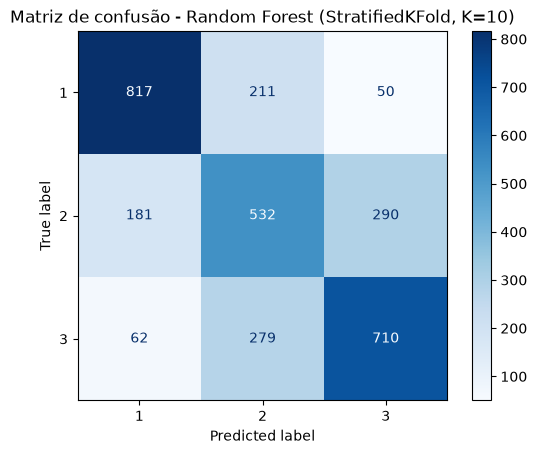

In [6]:
# Célula 6: relatório e matriz de confusão (predições de todos os folds)
y_pred = cross_val_predict(make_model(), X, y, cv=cv, n_jobs=1)

print(classification_report(y, y_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y, y_pred, cmap="Blues")
plt.title(f"Matriz de confusão - Random Forest (StratifiedKFold, K={K})")
plt.show()

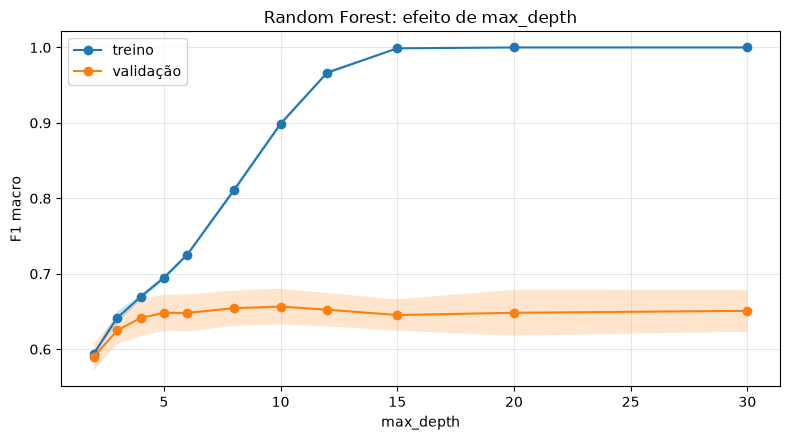

In [7]:
# Célula 7: curva de validação para max_depth (treino x validação)
profundidades = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 30]   # 30 ~ "sem limite"

train_scores, val_scores = validation_curve(
    make_model(), X, y,
    param_name="rf__max_depth", param_range=profundidades,
    cv=cv, scoring="f1_macro", n_jobs=1,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
for scores, nome in [(train_scores, "treino"), (val_scores, "validação")]:
    m, s = scores.mean(axis=1), scores.std(axis=1)
    ax.plot(profundidades, m, marker="o", label=nome)
    ax.fill_between(profundidades, m - s, m + s, alpha=.2)
ax.set_xlabel("max_depth")
ax.set_ylabel("F1 macro")
ax.set_title("Random Forest: efeito de max_depth")
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

,importancia
shell_weight,0.2588
height,0.1402
viscera_weight,0.1348
whole_weight,0.1344
shucked_weight,0.1092
diameter,0.0937
length,0.0655
sex_I,0.0400
sex_F,0.0131
sex_M,0.0104


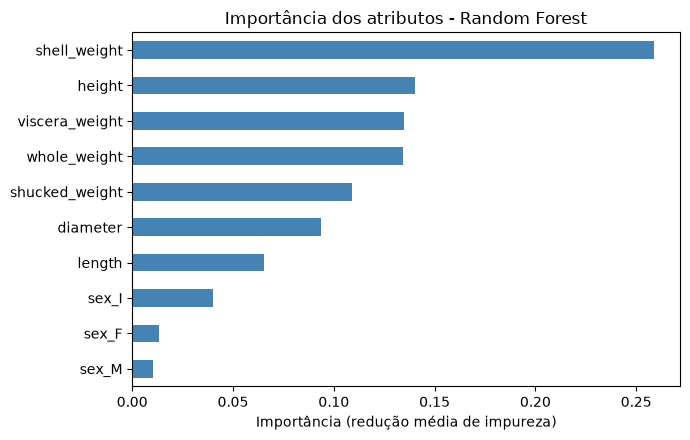

In [8]:
# Célula 8: importância dos atributos (modelo ajustado em todos os dados, só para análise)
modelo_final = make_model().fit(X, y)

nomes = [n.split("__")[-1] for n in modelo_final.named_steps["pre"].get_feature_names_out()]
importancias = pd.Series(
    modelo_final.named_steps["rf"].feature_importances_, index=nomes
).sort_values(ascending=False)

display(importancias.round(4).to_frame("importancia"))

importancias.sort_values().plot(kind="barh", figsize=(7, 4.5), color="steelblue")
plt.xlabel("Importância (redução média de impureza)")
plt.title("Importância dos atributos - Random Forest")
plt.tight_layout()
plt.show()

In [9]:
# Célula 10: comparar configurações de regularização
configs = [
    {"max_depth": 8,    "min_samples_leaf": 1,  "max_features": "sqrt"},   # atual
    {"max_depth": 8,    "min_samples_leaf": 5,  "max_features": "sqrt"},
    {"max_depth": 8,    "min_samples_leaf": 10, "max_features": "sqrt"},
    {"max_depth": 8,    "min_samples_leaf": 20, "max_features": "sqrt"},
    {"max_depth": None, "min_samples_leaf": 10, "max_features": "sqrt"},
    {"max_depth": None, "min_samples_leaf": 10, "max_features": 0.5},
    {"max_depth": None, "min_samples_leaf": 20, "max_features": 0.5},
]

rows = []
for cfg in configs:
    modelo = make_model()
    modelo.set_params(
        rf__max_depth=cfg["max_depth"],
        rf__min_samples_leaf=cfg["min_samples_leaf"],
        rf__max_features=cfg["max_features"],
    )
    r = cross_validate(
        modelo, X, y, cv=cv,
        scoring={"acc": "accuracy", "f1_macro": "f1_macro"},
        return_train_score=True, n_jobs=1,
    )
    rows.append({
        **cfg,
        "acc_treino": r["train_acc"].mean(),
        "acc_val": r["test_acc"].mean(),
        "acc_val_std": r["test_acc"].std(),
        "f1_macro_val": r["test_f1_macro"].mean(),
        "diferenca": r["train_acc"].mean() - r["test_acc"].mean(),
    })

df_cfg = pd.DataFrame(rows).sort_values("f1_macro_val", ascending=False)
display(df_cfg.round(4))

,max_depth,min_samples_leaf,max_features,acc_treino,acc_val,acc_val_std,f1_macro_val,diferenca
1,8.0,5,sqrt,0.7744,0.6622,0.0216,0.6594,0.1122
2,8.0,10,sqrt,0.7447,0.6612,0.0218,0.6579,0.0834
3,8.0,20,sqrt,0.7159,0.6619,0.0246,0.6576,0.0540
0,8.0,1,sqrt,0.8108,0.6574,0.0226,0.6544,0.1534
6,NaN,20,0.5,0.7259,0.6580,0.0204,0.6544,0.0678
5,NaN,10,0.5,0.7882,0.6571,0.0200,0.6535,0.1311
4,NaN,10,sqrt,0.7778,0.6552,0.0248,0.6515,0.1226


In [10]:
# Célula 11: imports e funções
from sklearn.model_selection import cross_val_score

def make_model_cols(cols, n_estimators=N_ESTIMATORS, n_jobs=1):
    """Pipeline que usa só as colunas em `cols` ('sex' entra com one-hot)."""
    transf = []
    if "sex" in cols:
        transf.append(("sex", OneHotEncoder(handle_unknown="ignore"), ["sex"]))
    nums = [c for c in cols if c != "sex"]
    if nums:
        transf.append(("num", "passthrough", nums))
    rf = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=MAX_DEPTH,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        random_state=RANDOM_STATE, n_jobs=n_jobs,
    )
    return Pipeline([("pre", ColumnTransformer(transf)), ("rf", rf)])


def score_cols(cols, X, y, cv, n_estimators=N_ESTIMATORS):
    s = cross_val_score(make_model_cols(cols, n_estimators), X[cols], y,
                        cv=cv, scoring="f1_macro", n_jobs=-1)
    return s.mean(), s.std()


def backward_elimination(X, y, cv, min_features=1, n_estimators=N_ESTIMATORS, verbose=True):
    atual = list(X.columns)
    m, s = score_cols(atual, X, y, cv, n_estimators)
    hist = [{"n_atributos": len(atual), "removido": None,
             "atributos": tuple(atual), "f1_media": m, "f1_std": s}]
    if verbose:
        print(f"{len(atual)} atributos | F1={m:.4f} ± {s:.4f}")

    while len(atual) > min_features:
        candidatos = {}
        for f in atual:
            resto = [c for c in atual if c != f]
            candidatos[f] = score_cols(resto, X, y, cv, n_estimators)
        removido = max(candidatos, key=lambda f: candidatos[f][0])
        atual.remove(removido)
        m, s = candidatos[removido]
        hist.append({"n_atributos": len(atual), "removido": removido,
                     "atributos": tuple(atual), "f1_media": m, "f1_std": s})
        if verbose:
            print(f"{len(atual)} atributos | removeu {removido:<15s} | F1={m:.4f} ± {s:.4f}")
    return pd.DataFrame(hist)


def escolher_subconjunto(hist):
    """Retorna (subconjunto de melhor F1, subconjunto mais enxuto dentro de 1 desvio padrão do melhor)."""
    i_melhor = hist["f1_media"].idxmax()
    limite = hist.loc[i_melhor, "f1_media"] - hist.loc[i_melhor, "f1_std"]
    elegiveis = hist[hist["f1_media"] >= limite]
    i_enxuto = elegiveis["n_atributos"].idxmin()
    return list(hist.loc[i_melhor, "atributos"]), list(hist.loc[i_enxuto, "atributos"])

8 atributos | F1=0.6537 ± 0.0241
7 atributos | removeu length          | F1=0.6547 ± 0.0175
6 atributos | removeu viscera_weight  | F1=0.6537 ± 0.0106
5 atributos | removeu diameter        | F1=0.6531 ± 0.0127
4 atributos | removeu height          | F1=0.6528 ± 0.0200
3 atributos | removeu shell_weight    | F1=0.6390 ± 0.0236
2 atributos | removeu sex             | F1=0.6359 ± 0.0159
1 atributos | removeu shucked_weight  | F1=0.5512 ± 0.0189

Melhor F1:             ['sex', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight']
Mais enxuto (1 desvio): ['sex', 'whole_weight', 'shucked_weight']


,n_atributos,removido,f1_media,f1_std
0,8,NaN,0.6537,0.0241
1,7,length,0.6547,0.0175
2,6,viscera_weight,0.6537,0.0106
3,5,diameter,0.6531,0.0127
4,4,height,0.6528,0.0200
5,3,shell_weight,0.6390,0.0236
6,2,sex,0.6359,0.0159
7,1,shucked_weight,0.5512,0.0189


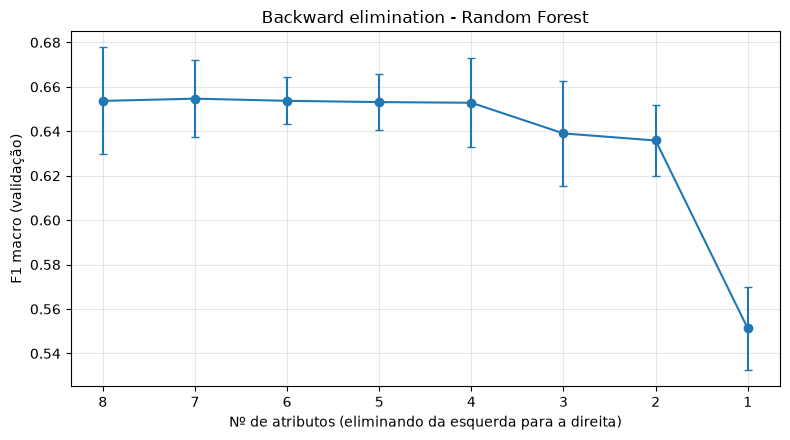

In [11]:
# Célula 12: rodar a eliminação e ver o resultado
cv_sel = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

hist = backward_elimination(X, y, cv_sel)

melhor, enxuto = escolher_subconjunto(hist)
print("\nMelhor F1:            ", melhor)
print("Mais enxuto (1 desvio):", enxuto)

display(hist[["n_atributos", "removido", "f1_media", "f1_std"]].round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(hist["n_atributos"], hist["f1_media"], yerr=hist["f1_std"],
            marker="o", capsize=3)
ax.invert_xaxis()
ax.set_xlabel("Nº de atributos (eliminando da esquerda para a direita)")
ax.set_ylabel("F1 macro (validação)")
ax.set_title("Backward elimination - Random Forest")
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

In [12]:
# Célula 13: validação aninhada (estimativa honesta do desempenho com seleção)
# Demora: cada fold externo roda a eliminação completa. Para testar, use n_estimators=50
# e menos folds.
externo = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
interno = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE + 1)

accs, f1s, escolhidos = [], [], []
for i, (tr, te) in enumerate(externo.split(X, y), start=1):
    Xtr, ytr, Xte, yte = X.iloc[tr], y.iloc[tr], X.iloc[te], y.iloc[te]

    h = backward_elimination(Xtr, ytr, interno, verbose=False)
    _, cols = escolher_subconjunto(h)

    modelo = make_model_cols(cols, n_jobs=-1).fit(Xtr[cols], ytr)
    pred = modelo.predict(Xte[cols])

    accs.append(accuracy_score(yte, pred))
    f1s.append(f1_score(yte, pred, average="macro"))
    escolhidos.append(cols)
    print(f"Fold {i}: acc={accs[-1]:.4f} | f1={f1s[-1]:.4f} | {cols}")

print(f"\nAcurácia: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"F1 macro: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

# frequência com que cada atributo foi mantido nos folds
freq = pd.Series([c for cols in escolhidos for c in cols]).value_counts()
display(freq.to_frame("vezes_mantido").assign(de=len(escolhidos)))

Fold 1: acc=0.6667 | f1=0.6564 | ['height', 'shucked_weight', 'shell_weight']
Fold 2: acc=0.6332 | f1=0.6304 | ['sex', 'whole_weight', 'shucked_weight', 'shell_weight']
Fold 3: acc=0.6486 | f1=0.6494 | ['whole_weight', 'shucked_weight', 'shell_weight']
Fold 4: acc=0.6565 | f1=0.6542 | ['height', 'shucked_weight', 'shell_weight']
Fold 5: acc=0.6262 | f1=0.6204 | ['whole_weight', 'shucked_weight', 'shell_weight']

Acurácia: 0.6462 ± 0.0148
F1 macro: 0.6421 ± 0.0142


,vezes_mantido,de
shucked_weight,5,5
shell_weight,5,5
whole_weight,3,5
height,2,5
sex,1,5
